In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, root_mean_squared_error

In [2]:
# Load data
df = pd.read_csv("/Users/mariahloehr/IICD/IICD/Data/cell_cycle_tidied.csv")

# Separate features and target
X = df.drop(columns=['phase', 'age', 'PHATE_1', 'PHATE_2'])
y = df['age']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=949)

/Users/mariahloehr/IICD/IICD/sklearn-env/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:780: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/mariahloehr/IICD/IICD/sklearn-env/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:780: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/mariahloehr/IICD/IICD/sklearn-env/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:780: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/mariahloehr/IICD/IICD/sklearn-env/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:780: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't conv

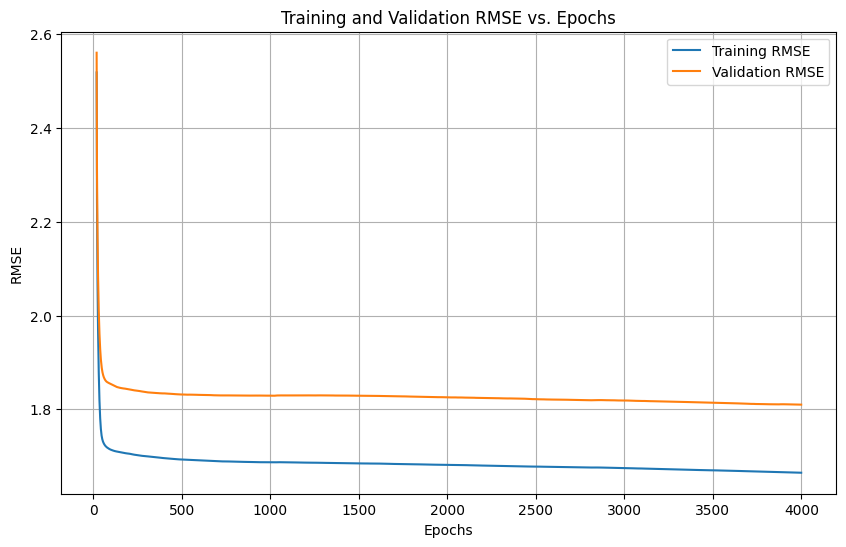

In [4]:
# tuning epochs

mlp = MLPRegressor(max_iter=1, 
                   hidden_layer_sizes = (300,300,300), 
                   learning_rate = 'adaptive', 
                   learning_rate_init = 0.0001, 
                   alpha = 100,
                   random_state=949,
                   warm_start=True)

# track rmse
n_epochs = 4000

train_rmse = []
val_rmse = []
epochs_recorded = []

def moving_average(data, window_size=20):
    return np.convolve(data, np.ones(window_size)/window_size, mode='valid')

for epoch in range(1, n_epochs):
    mlp.fit(X_train, y_train)  # One epoch
    
    y_tr_pred = mlp.predict(X_train)
    y_val_pred = mlp.predict(X_test)
    
    train_rmse.append(root_mean_squared_error(y_train, y_tr_pred))
    val_rmse.append(root_mean_squared_error(y_test, y_val_pred))
    epochs_recorded.append(epoch)

smoothed_val_rmse = moving_average(val_rmse, window_size=20)
smoothed_train_rmse = moving_average(train_rmse, window_size=20)
epochs_smoothed = np.arange(20, len(val_rmse)+1)

# Plot
plt.figure(figsize=(10,6))
plt.plot(epochs_smoothed, smoothed_train_rmse, label='Training RMSE')
plt.plot(epochs_smoothed, smoothed_val_rmse, label='Validation RMSE')
plt.xlabel('Epochs')
plt.ylabel('RMSE')
plt.title('Training and Validation RMSE vs. Epochs')
plt.legend()
plt.grid(True)
plt.show()